
# Double-QD 2D Barrier-Gate Sweep (No Screening Charge)

This notebook runs the 2D double quantum dot input with the three barrier gates locked together and swept from **+3.0 V** to **-3.0 V** in **0.5 V** steps.

The postprocessing focuses on how the electrostatics and hole accumulation evolve through the sweep:
- `potential.fld` GIF
- `density_hole.fld` GIF
- `bandedges.fld` (`HH`) GIF
- `electric_field_norm.fld` GIF
- `potential_1d_x_QD.dat` GIF
- `density_hole_1d_x_QD.dat` GIF

A few compact scalar diagnostics are also extracted so we can see how the QW hole density and the dot/barrier linecuts evolve with the shared barrier voltage.



## Setup

`nextnanopy.Sweep` performs a Cartesian-product sweep, so it is **not** used here.  
Instead, this notebook runs a controlled loop over 13 bias points, with `V_BG1 = V_BG2 = V_BG3` at every step.


In [70]:

import sys
import time
import io
import json
import re
import shutil
import importlib
from pathlib import Path

import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

REPO_ROOT = Path('/Users/robertjovanov/code/qpu-design-automation-toolkit').resolve()
SRC = REPO_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import nextnanopp_tools as nnt
nnt = importlib.reload(nnt)

plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.22


In [71]:

INPUT_PATH = REPO_ROOT / 'configs' / 'robert_inputs' / 'double_qd' / '2d' / 'Double_Quantum_Dot_2D_no_screening_charge.in'
SWEEP_ROOT = REPO_ROOT / 'runs' / 'Double_Quantum_Dot_2D_no_screening_charge_barrier_sweep_locked'
ARTIFACT_DIR = REPO_ROOT / 'notebooks' / 'analysis' / 'artifacts' / 'double_qd_2d_barrier_gate_sweep_no_screening'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
SWEEP_ROOT.mkdir(parents=True, exist_ok=True)

BIAS_FOLDER = 'bias_00000'
GIF_FRAME_DURATION_MS = 1800
GIF_LAST_FRAME_DURATION_MS = 3000
FORCE_RERUN = False

V_BG_VALUES = np.round(np.arange(3.0, -3.0 - 1e-12, -0.5), 10).tolist()

pd.DataFrame({
    'quantity': ['input', 'sweep_root', 'artifact_dir', 'n_points'],
    'value': [str(INPUT_PATH), str(SWEEP_ROOT), str(ARTIFACT_DIR), len(V_BG_VALUES)],
})


,quantity,value
0,input,/Users/robertjovanov/code/qpu-design-automatio...
1,sweep_root,/Users/robertjovanov/code/qpu-design-automatio...
2,artifact_dir,/Users/robertjovanov/code/qpu-design-automatio...
3,n_points,13


In [72]:

def normalize_bias(value: float) -> float:
    value = float(value)
    return 0.0 if abs(value) < 1e-12 else value


def format_bias_token(value: float) -> str:
    value = normalize_bias(value)
    return f"{value:+.1f}".replace('+', 'p').replace('-', 'm').replace('.', 'p')


def format_bias_label(value: float) -> str:
    value = normalize_bias(value)
    return f"{value:+.1f} V"


def make_run_name(input_stem: str, value: float) -> str:
    return f"{input_stem}__V_BG_{format_bias_token(value)}V"


def candidate_run_dirs(sweep_root: str | Path, run_name: str) -> list[Path]:
    sweep_root = Path(sweep_root)
    matches: list[Path] = []
    pattern = re.compile(rf"^{re.escape(run_name)}(?:__\d+)?$")
    for path in sweep_root.iterdir():
        if path.is_dir() and pattern.fullmatch(path.name):
            matches.append(path)
    return sorted(matches, key=lambda path: path.name)


def resolve_preferred_run_root(sweep_root: str | Path, run_name: str) -> tuple[Path, bool]:
    candidates = candidate_run_dirs(sweep_root, run_name)
    complete = [path for path in candidates if run_is_complete(path)]
    if complete:
        return complete[-1], True
    if candidates:
        return candidates[-1], False
    return Path(sweep_root) / run_name, False


def run_is_complete(run_root: str | Path) -> bool:
    run_root = Path(run_root)
    return (run_root / 'job_done.txt').exists() and (run_root / BIAS_FOLDER).exists()


def parse_variables_input(path: str | Path) -> dict[str, float | str]:
    values: dict[str, float | str] = {}
    for raw_line in Path(path).read_text().splitlines():
        line = raw_line.strip()
        if not line.startswith('$') or '=' not in line:
            continue
        name, raw_value = line.split('=', 1)
        key = name.strip().lstrip('$')
        value_text = raw_value.split('#', 1)[0].strip()
        try:
            values[key] = float(value_text)
        except ValueError:
            values[key] = value_text
    return values


def sample_nearest(x: np.ndarray, y: np.ndarray, target: float) -> tuple[float, float]:
    idx = int(np.argmin(np.abs(x - target)))
    return float(x[idx]), float(y[idx])


def fig_to_frame(fig) -> np.ndarray:
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    return imageio.imread(buf)


def save_gif(frames: list[np.ndarray], path: str | Path, duration_ms: int | None = None, last_frame_duration_ms: int | None = None) -> Path:
    if duration_ms is None:
        duration_ms = GIF_FRAME_DURATION_MS
    if last_frame_duration_ms is None:
        last_frame_duration_ms = GIF_LAST_FRAME_DURATION_MS
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    durations = [int(duration_ms)] * len(frames)
    if durations:
        durations[-1] = int(last_frame_duration_ms)
    imageio.mimsave(path, frames, duration=durations, loop=0)
    return path


def load_linecut(path: str | Path, ycol: str | None = None) -> tuple[np.ndarray, np.ndarray, str, str]:
    df = pd.read_csv(Path(path), sep=r'\s+', comment='#')
    xcol = df.columns[0]
    ycol = ycol or df.columns[-1]
    return df[xcol].to_numpy(dtype=float), df[ycol].to_numpy(dtype=float), xcol, ycol


def load_fld_dataset(path: str | Path, variable: str | None = None, log10: bool = False, floor: float | None = None):
    ds = nnt.load_output_file(Path(path), prefer_nextnanopy=False)
    x = np.asarray(ds.get_coord('x').value, dtype=float)
    z = np.asarray(ds.get_coord('z').value, dtype=float)
    if variable is None:
        if len(ds.variable_names) != 1:
            raise ValueError(f"Specify variable for {Path(path).name}. Choices: {ds.variable_names}")
        var = ds.get_variable(ds.variable_names[0])
    else:
        var = ds.get_variable(variable)
    values = np.asarray(var.value, dtype=float)
    if values.shape == (len(z), len(x)):
        grid = values
    elif values.shape == (len(x), len(z)):
        grid = values.T
    else:
        raise ValueError(f"Unexpected grid shape {values.shape} for {Path(path).name}")
    label = var.label or var.name
    if log10:
        floor = 1e-12 if floor is None else float(floor)
        grid = np.log10(np.clip(grid, floor, None))
        label = f"log10({label})"
    return x, z, grid, label


def build_manifest(input_path: Path, sweep_root: Path, values: list[float], force_rerun: bool = False) -> pd.DataFrame:
    records: list[dict[str, object]] = []
    t0 = time.perf_counter()

    for idx, vbg in enumerate(values, start=1):
        run_name = make_run_name(input_path.stem, vbg)
        action = 'existing'
        elapsed_s = np.nan

        if force_rerun:
            for path in candidate_run_dirs(sweep_root, run_name):
                shutil.rmtree(path)

        run_root, is_complete = resolve_preferred_run_root(sweep_root, run_name)

        if not is_complete:
            print(f"[{idx:02d}/{len(values):02d}] Running locked barrier sweep point {format_bias_label(vbg)}")
            start = time.perf_counter()
            result = nnt.run_input_file(
                input_path,
                output_root=sweep_root,
                run_name=run_name,
                add_timestamp=False,
                variables={'V_BG1': float(vbg), 'V_BG2': float(vbg), 'V_BG3': float(vbg)},
                show_log=False,
                convergenceCheck=True,
                execute_kwargs={'overwrite': True},
            )
            run_root = nnt.get_output_directory(result)
            action = 'ran'
            elapsed_s = time.perf_counter() - start
        else:
            print(f"[{idx:02d}/{len(values):02d}] Reusing existing result {run_root.name}")

        records.append({
            'V_BG': float(vbg),
            'run_name': run_name,
            'run_root': str(run_root),
            'status': action,
            'elapsed_s': elapsed_s,
            'job_done': (run_root / 'job_done.txt').exists(),
        })

    manifest = pd.DataFrame(records).sort_values('V_BG', ascending=False, ignore_index=True)
    manifest.attrs['elapsed_total_s'] = time.perf_counter() - t0
    return manifest


def collect_summary_metrics(manifest_df: pd.DataFrame, x_probes: dict[str, float]) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for row in manifest_df.itertuples(index=False):
        run_root = Path(row.run_root)
        bias_dir = run_root / BIAS_FOLDER

        integrated = pd.read_csv(run_root / 'integrated_density_hole.dat', sep=r'\s+')
        integrated_row = integrated.iloc[0]

        x_den, y_den, _, _ = load_linecut(bias_dir / 'density_hole_1d_x_QD.dat')
        x_phi, y_phi, _, _ = load_linecut(bias_dir / 'potential_1d_x_QD.dat')

        peak_idx = int(np.nanargmax(y_den))
        metric_row: dict[str, object] = {
            'V_BG': float(row.V_BG),
            'run_name': row.run_name,
            'run_root': row.run_root,
            'status': row.status,
            'sheet_qw_e_per_cm': float(integrated_row.get('region_3[carriers/cm]', np.nan)),
            'sheet_cap_e_per_cm': float(integrated_row.get('region_4[carriers/cm]', np.nan)),
            'sheet_topcap_e_per_cm': float(integrated_row.get('region_5[carriers/cm]', np.nan)),
            'max_density_xQD_1e18_cm^-3': float(np.nanmax(y_den)),
            'x_at_max_density_nm': float(x_den[peak_idx]),
            'potential_min_xQD_V': float(np.nanmin(y_phi)),
            'potential_max_xQD_V': float(np.nanmax(y_phi)),
        }

        text = (bias_dir / 'total_charges.txt').read_text()
        holes_match = re.search(r'^holes:\s+([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)', text, flags=re.MULTILINE)
        metric_row['total_holes_e_per_cm'] = float(holes_match.group(1)) if holes_match else np.nan

        for probe_name, probe_x in x_probes.items():
            x_sample_den, y_sample_den = sample_nearest(x_den, y_den, probe_x)
            x_sample_phi, y_sample_phi = sample_nearest(x_phi, y_phi, probe_x)
            metric_row[f'x_{probe_name}_sample_nm'] = x_sample_den
            metric_row[f'density_at_{probe_name}_1e18_cm^-3'] = y_sample_den
            metric_row[f'potential_at_{probe_name}_V'] = y_sample_phi

        rows.append(metric_row)

    return pd.DataFrame(rows).sort_values('V_BG', ascending=False, ignore_index=True)


def make_fld_gif(
    summary_df: pd.DataFrame,
    rel_file: str,
    out_path: str | Path,
    *,
    variable: str | None = None,
    title_prefix: str,
    cmap: str = 'viridis',
    log10: bool = False,
    floor: float | None = None,
    xlim: tuple[float, float] | None = None,
    ylim: tuple[float, float] | None = None,
    vmin: float | None = None,
    vmax: float | None = None,
):
    datasets = []
    for row in summary_df.itertuples(index=False):
        x, z, grid, label = load_fld_dataset(Path(row.run_root) / BIAS_FOLDER / rel_file, variable=variable, log10=log10, floor=floor)
        datasets.append({'V_BG': float(row.V_BG), 'x': x, 'z': z, 'grid': grid, 'label': label})

    finite_values = np.concatenate([d['grid'][np.isfinite(d['grid'])] for d in datasets if np.isfinite(d['grid']).any()])
    if vmin is None:
        vmin = float(np.nanmin(finite_values))
    if vmax is None:
        vmax = float(np.nanmax(finite_values))

    frames = []
    for d in datasets:
        fig, ax = plt.subplots(figsize=(7.0, 4.8))
        image = ax.imshow(
            d['grid'],
            origin='lower',
            aspect='auto',
            extent=[d['x'].min(), d['x'].max(), d['z'].min(), d['z'].max()],
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(f"{title_prefix}\nV_BG1 = V_BG2 = V_BG3 = {format_bias_label(d['V_BG'])}")
        ax.set_xlabel('x (nm)')
        ax.set_ylabel('z (nm)')
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)
        cbar = fig.colorbar(image, ax=ax)
        cbar.set_label(d['label'])
        fig.tight_layout()
        frames.append(fig_to_frame(fig))

    return save_gif(frames, out_path)


def make_linecut_gif(
    summary_df: pd.DataFrame,
    rel_file: str,
    out_path: str | Path,
    *,
    title_prefix: str,
    xlim: tuple[float, float] | None = None,
    ylim: tuple[float, float] | None = None,
    yscale: str = 'linear',
    floor: float | None = None,
):
    curves = []
    for row in summary_df.itertuples(index=False):
        x, y, xcol, ycol = load_linecut(Path(row.run_root) / BIAS_FOLDER / rel_file)
        if yscale == 'log':
            floor = 1e-12 if floor is None else float(floor)
            y = np.clip(y, floor, None)
        curves.append({'V_BG': float(row.V_BG), 'x': x, 'y': y, 'xcol': xcol, 'ycol': ycol})

    if ylim is None:
        all_values = np.concatenate([curve['y'][np.isfinite(curve['y'])] for curve in curves])
        if yscale == 'log':
            ymin = float(np.nanmin(all_values))
            ymax = float(np.nanmax(all_values))
            ylim = (ymin, ymax)
        else:
            span = float(np.nanmax(all_values) - np.nanmin(all_values))
            pad = 0.05 * (span + 1e-15)
            ylim = (float(np.nanmin(all_values) - pad), float(np.nanmax(all_values) + pad))

    frames = []
    for curve in curves:
        fig, ax = plt.subplots(figsize=(6.6, 4.0))
        ax.plot(curve['x'], curve['y'], linewidth=2.1)
        ax.set_title(f"{title_prefix}\nV_BG1 = V_BG2 = V_BG3 = {format_bias_label(curve['V_BG'])}")
        ax.set_xlabel(curve['xcol'])
        ax.set_ylabel(curve['ycol'])
        ax.set_yscale(yscale)
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)
        fig.tight_layout()
        frames.append(fig_to_frame(fig))

    return save_gif(frames, out_path)


def plot_linecut_family(summary_df: pd.DataFrame, rel_file: str, *, ax, title: str, yscale: str = 'linear', floor: float | None = None, xlim=None):
    colors = plt.cm.cividis(np.linspace(0.0, 1.0, len(summary_df)))
    for color, row in zip(colors, summary_df.itertuples(index=False)):
        x, y, xcol, ycol = load_linecut(Path(row.run_root) / BIAS_FOLDER / rel_file)
        if yscale == 'log':
            floor = 1e-12 if floor is None else float(floor)
            y = np.clip(y, floor, None)
        ax.plot(x, y, color=color, linewidth=1.5, label=f"{row.V_BG:+.1f} V")
    ax.set_title(title)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.set_yscale(yscale)
    if xlim is not None:
        ax.set_xlim(*xlim)


## Run The Locked Barrier-Gate Sweep

In [73]:

MANIFEST = build_manifest(INPUT_PATH, SWEEP_ROOT, V_BG_VALUES, force_rerun=FORCE_RERUN)
MANIFEST_PATH = ARTIFACT_DIR / 'sweep_manifest.csv'
MANIFEST.to_csv(MANIFEST_PATH, index=False)

elapsed_total_s = MANIFEST.attrs.get('elapsed_total_s', np.nan)
print(f"Sweep check finished in {elapsed_total_s/60:.2f} min")
display(MANIFEST)
print(f"Manifest saved to: {MANIFEST_PATH}")


[01/13] Reusing existing result Double_Quantum_Dot_2D_no_screening_charge__V_BG_p3p0V
[02/13] Reusing existing result Double_Quantum_Dot_2D_no_screening_charge__V_BG_p2p5V
[03/13] Reusing existing result Double_Quantum_Dot_2D_no_screening_charge__V_BG_p2p0V
[04/13] Reusing existing result Double_Quantum_Dot_2D_no_screening_charge__V_BG_p1p5V
[05/13] Reusing existing result Double_Quantum_Dot_2D_no_screening_charge__V_BG_p1p0V
[06/13] Reusing existing result Double_Quantum_Dot_2D_no_screening_charge__V_BG_p0p5V
[07/13] Reusing existing result Double_Quantum_Dot_2D_no_screening_charge__V_BG_p0p0V
[08/13] Reusing existing result Double_Quantum_Dot_2D_no_screening_charge__V_BG_m0p5V
[09/13] Reusing existing result Double_Quantum_Dot_2D_no_screening_charge__V_BG_m1p0V
[10/13] Reusing existing result Double_Quantum_Dot_2D_no_screening_charge__V_BG_m1p5V
[11/13] Reusing existing result Double_Quantum_Dot_2D_no_screening_charge__V_BG_m2p0V
[12/13] Reusing existing result Double_Quantum_Dot_2D_

,V_BG,run_name,run_root,status,elapsed_s,job_done
0,3.0,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,NaN,True
1,2.5,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,NaN,True
2,2.0,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,NaN,True
3,1.5,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,NaN,True
4,1.0,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,NaN,True
5,0.5,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,NaN,True
6,0.0,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,NaN,True
7,-0.5,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,NaN,True
8,-1.0,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,NaN,True
9,-1.5,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,NaN,True


Manifest saved to: /Users/robertjovanov/code/qpu-design-automation-toolkit/notebooks/analysis/artifacts/double_qd_2d_barrier_gate_sweep_no_screening/sweep_manifest.csv


## Geometry And Analysis Windows

In [74]:

REFERENCE_RUN = Path(MANIFEST.iloc[0]['run_root'])
REFERENCE_VARS = parse_variables_input(REFERENCE_RUN / 'variables_input.txt')

X_PROBES = {
    'PG1': float(REFERENCE_VARS['x_PG1_center']),
    'BG2': float(REFERENCE_VARS['x_BG2_center']),
    'PG2': float(REFERENCE_VARS['x_PG2_center']),
}

X_WINDOW = (float(REFERENCE_VARS['x_QR_left']) - 30.0, float(REFERENCE_VARS['x_QR_right']) + 30.0)
Z_WINDOW = (float(REFERENCE_VARS['z_GeQW']) - 25.0, float(REFERENCE_VARS['z_PG_end']) + 10.0)
Z_LINE_WINDOW = (float(REFERENCE_VARS['z_GeQW']) - 60.0, float(REFERENCE_VARS['z_PG_end']) + 5.0)

geometry_summary = pd.DataFrame({
    'quantity': [
        'x_PG1_center', 'x_BG2_center', 'x_PG2_center',
        'x_QR_left', 'x_QR_right', 'z_GeQW', 'z_PG_end',
        'X_WINDOW', 'Z_WINDOW', 'Z_LINE_WINDOW'
    ],
    'value': [
        REFERENCE_VARS['x_PG1_center'], REFERENCE_VARS['x_BG2_center'], REFERENCE_VARS['x_PG2_center'],
        REFERENCE_VARS['x_QR_left'], REFERENCE_VARS['x_QR_right'], REFERENCE_VARS['z_GeQW'], REFERENCE_VARS['z_PG_end'],
        X_WINDOW, Z_WINDOW, Z_LINE_WINDOW,
    ],
})

display(geometry_summary)


,quantity,value
0,x_PG1_center,1150.0
1,x_BG2_center,1240.0
2,x_PG2_center,1330.0
3,x_QR_left,1020.0
4,x_QR_right,1460.0
5,z_GeQW,4015.0
6,z_PG_end,4188.0
7,X_WINDOW,"(990.0, 1490.0)"
8,Z_WINDOW,"(3990.0, 4198.0)"
9,Z_LINE_WINDOW,"(3955.0, 4193.0)"


## Scalar Diagnostics

In [75]:

SUMMARY = collect_summary_metrics(MANIFEST, X_PROBES)
SUMMARY_PATH = ARTIFACT_DIR / 'summary_metrics.csv'
SUMMARY.to_csv(SUMMARY_PATH, index=False)

display(SUMMARY)
print(f"Summary saved to: {SUMMARY_PATH}")


,V_BG,run_name,run_root,status,sheet_qw_e_per_cm,sheet_cap_e_per_cm,sheet_topcap_e_per_cm,max_density_xQD_1e18_cm^-3,x_at_max_density_nm,potential_min_xQD_V,...,total_holes_e_per_cm,x_PG1_sample_nm,density_at_PG1_1e18_cm^-3,potential_at_PG1_V,x_BG2_sample_nm,density_at_BG2_1e18_cm^-3,potential_at_BG2_V,x_PG2_sample_nm,density_at_PG2_1e18_cm^-3,potential_at_PG2_V
0,3.0,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,1.155990e-298,1.224154e-299,1.084505e-302,4.455063e-306,1310.0,2.130000,...,1.573377e-298,1150.0,3.938477e-306,2.267392,1240.0,1.398921e-306,2.279493,1330.0,3.938477e-306,2.267392
1,2.5,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,1.152210e-298,1.267063e-299,1.084505e-302,4.593166e-306,1310.0,2.130000,...,1.574086e-298,1150.0,4.055805e-306,2.245908,1240.0,1.453757e-306,2.257362,1330.0,4.055805e-306,2.245908
2,2.0,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,1.151404e-298,1.297736e-299,1.084505e-302,4.673339e-306,1170.0,2.130000,...,1.574251e-298,1150.0,4.100292e-306,2.215307,1240.0,1.527927e-306,2.225937,1330.0,4.100292e-306,2.215307
3,1.5,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,1.150513e-298,1.331418e-299,1.084505e-302,4.849018e-306,1165.0,2.130000,...,1.574434e-298,1150.0,3.769611e-306,2.170037,1240.0,1.756227e-306,2.179465,1330.0,3.769559e-306,2.170037
4,1.0,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,1.149514e-298,1.370076e-299,1.084505e-302,5.075841e-306,1305.0,2.087725,...,1.574632e-298,1150.0,3.544549e-306,2.095310,1240.0,2.240989e-306,2.102952,1330.0,3.544549e-306,2.095310
5,0.5,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,1.144115e-298,1.456803e-299,1.084505e-302,5.187819e-306,1305.0,1.854166,...,1.575642e-298,1150.0,2.414627e-306,1.865510,1240.0,3.179276e-306,1.863379,1330.0,2.414627e-306,1.865510
6,0.0,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,6.618488e+06,8.643654e+04,1.084505e-302,3.303312e-01,1160.0,1.785681,...,6.651586e+06,1150.0,3.238085e-01,1.785769,1240.0,1.698208e-01,1.788357,1330.0,3.238085e-01,1.785769
7,-0.5,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,1.770254e+07,4.006875e+05,1.084505e-302,6.786406e-01,1160.0,1.782448,...,1.781898e+07,1150.0,6.727152e-01,1.782490,1240.0,5.123228e-01,1.783881,1330.0,6.727152e-01,1.782490
8,-1.0,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,3.033768e+07,1.094337e+06,1.084505e-302,1.062767e+00,1320.0,1.779987,...,3.059138e+07,1150.0,1.053586e+00,1.780033,1240.0,9.486392e-01,1.780630,1330.0,1.053586e+00,1.780033
9,-1.5,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...,existing,4.269733e+07,2.067222e+06,1.357346e+06,1.446589e+00,1300.0,1.778136,...,4.456187e+07,1150.0,1.426511e+00,1.778208,1240.0,1.418769e+00,1.778243,1330.0,1.426511e+00,1.778208


Summary saved to: /Users/robertjovanov/code/qpu-design-automation-toolkit/notebooks/analysis/artifacts/double_qd_2d_barrier_gate_sweep_no_screening/summary_metrics.csv


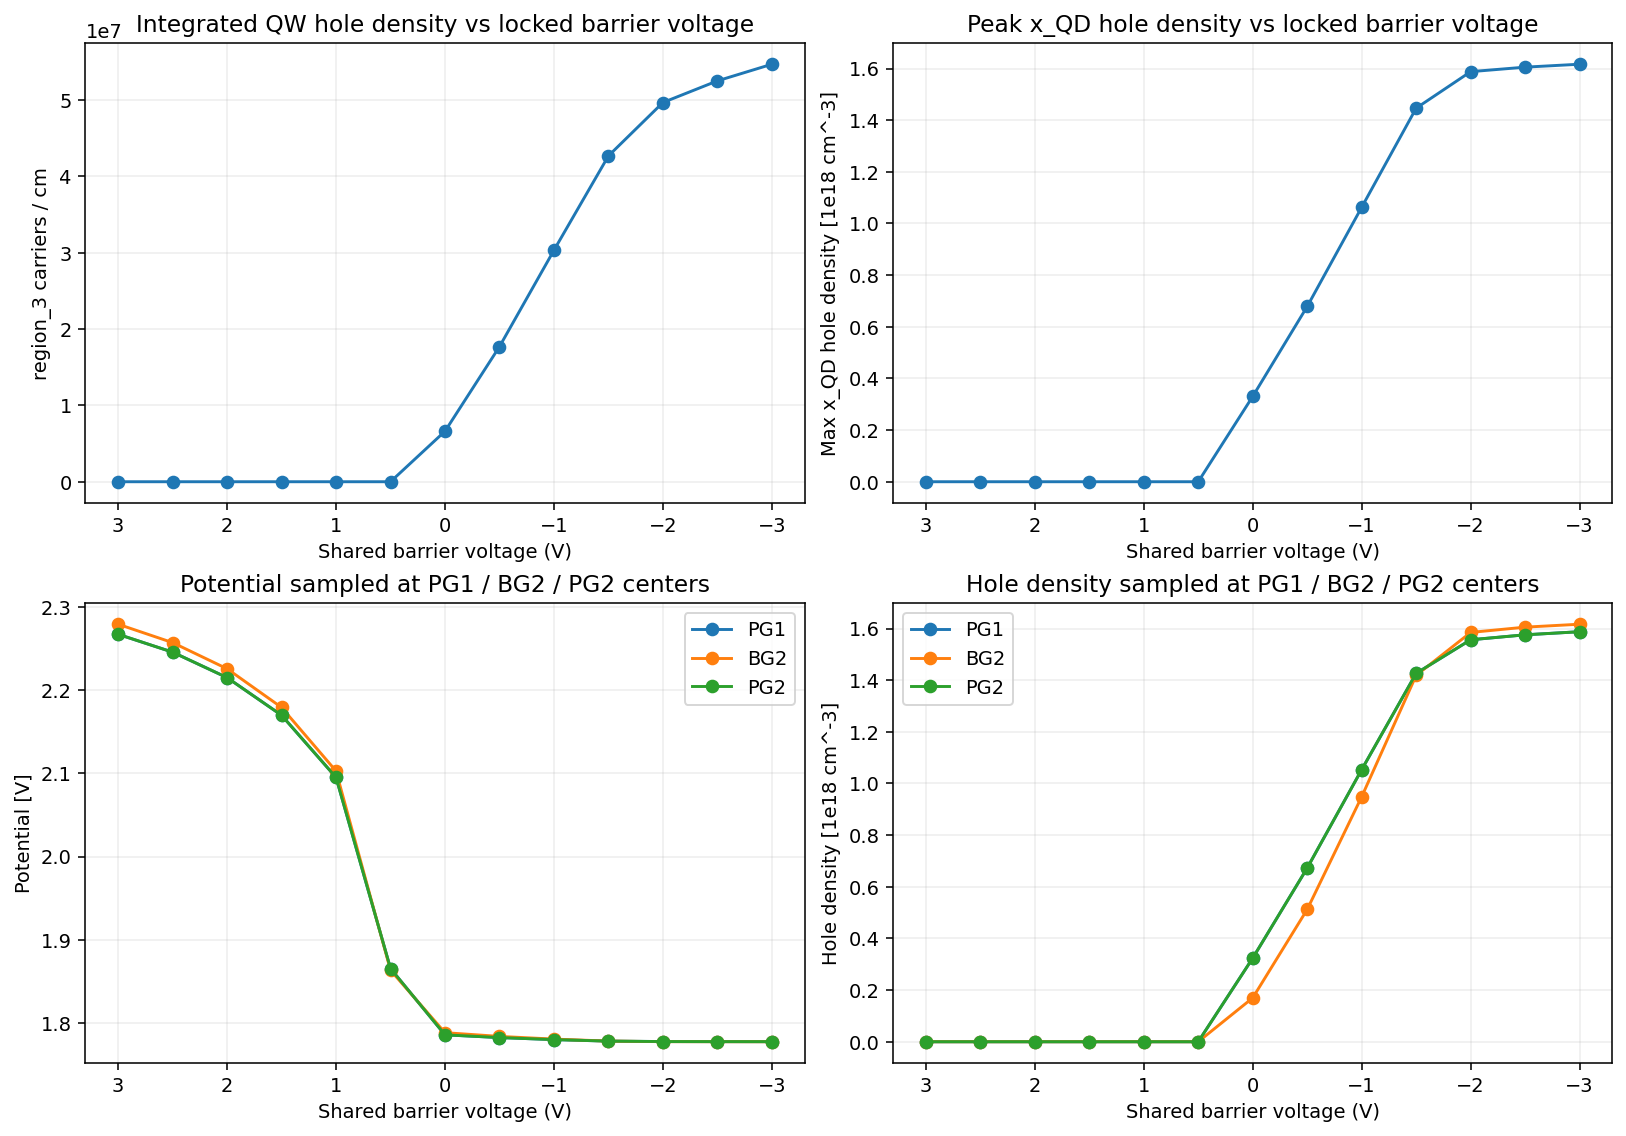

In [76]:

fig, axes = plt.subplots(2, 2, figsize=(11.5, 8.0), constrained_layout=True)

axes[0, 0].plot(SUMMARY['V_BG'], SUMMARY['sheet_qw_e_per_cm'], marker='o')
axes[0, 0].set_title('Integrated QW hole density vs locked barrier voltage')
axes[0, 0].set_xlabel('Shared barrier voltage (V)')
axes[0, 0].set_ylabel('region_3 carriers / cm')

axes[0, 1].plot(SUMMARY['V_BG'], SUMMARY['max_density_xQD_1e18_cm^-3'], marker='o')
axes[0, 1].set_title('Peak x_QD hole density vs locked barrier voltage')
axes[0, 1].set_xlabel('Shared barrier voltage (V)')
axes[0, 1].set_ylabel('Max x_QD hole density [1e18 cm^-3]')

for probe in ['PG1', 'BG2', 'PG2']:
    axes[1, 0].plot(SUMMARY['V_BG'], SUMMARY[f'potential_at_{probe}_V'], marker='o', label=probe)
axes[1, 0].set_title('Potential sampled at PG1 / BG2 / PG2 centers')
axes[1, 0].set_xlabel('Shared barrier voltage (V)')
axes[1, 0].set_ylabel('Potential [V]')
axes[1, 0].legend()

for probe in ['PG1', 'BG2', 'PG2']:
    axes[1, 1].plot(SUMMARY['V_BG'], SUMMARY[f'density_at_{probe}_1e18_cm^-3'], marker='o', label=probe)
axes[1, 1].set_title('Hole density sampled at PG1 / BG2 / PG2 centers')
axes[1, 1].set_xlabel('Shared barrier voltage (V)')
axes[1, 1].set_ylabel('Hole density [1e18 cm^-3]')
axes[1, 1].legend()

for ax in axes.ravel():
    ax.invert_xaxis()

fig.savefig(ARTIFACT_DIR / 'scalar_diagnostics.png', dpi=180, bbox_inches='tight')
plt.show()


## Linecut Families

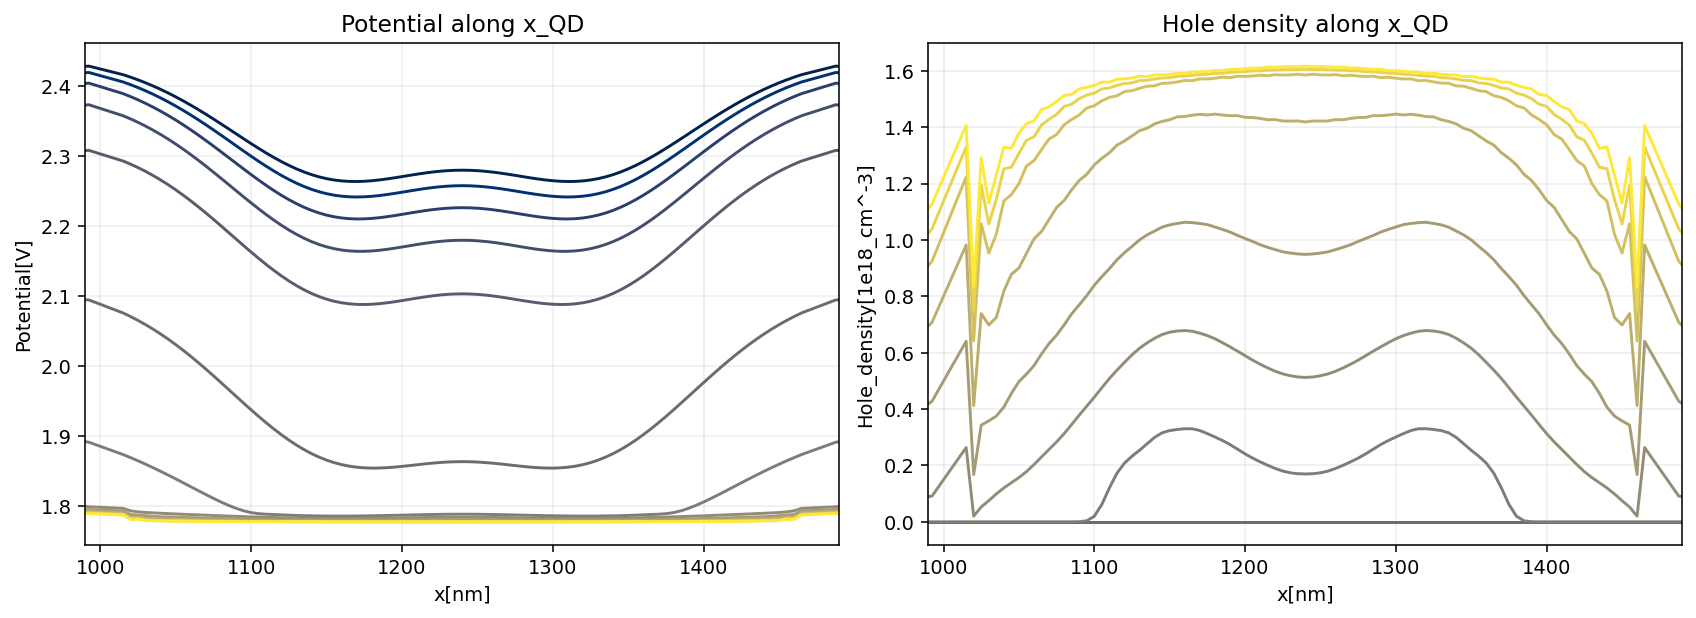

In [77]:

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3), constrained_layout=True)
plot_linecut_family(SUMMARY, 'potential_1d_x_QD.dat', ax=axes[0], title='Potential along x_QD', xlim=X_WINDOW)
plot_linecut_family(SUMMARY, 'density_hole_1d_x_QD.dat', ax=axes[1], title='Hole density along x_QD', floor=1e-6, xlim=X_WINDOW)
fig.savefig(ARTIFACT_DIR / 'xQD_linecut_families.png', dpi=180, bbox_inches='tight')
plt.show()


## Build Summaries And GIFs

In [78]:

PLOT_PATHS = {
    'integrated_density_regions': ARTIFACT_DIR / 'integrated_hole_density_regions_vs_locked_barrier.png',
}

TABLE_PATHS = {
    'integrated_density_regions': ARTIFACT_DIR / 'integrated_hole_density_regions_vs_locked_barrier.csv',
    'total_charges_summary': ARTIFACT_DIR / 'total_charges_summary.csv',
}

GIF_PATHS = {
    'bandedges_xQD_hh_hole_fermi': ARTIFACT_DIR / 'bandedges_1d_x_QD_hh_hole_fermi_vs_locked_barrier.gif',
    'bandedges_z_BG2_hh_hole_fermi': ARTIFACT_DIR / 'bandedges_1d_z_BG2_hh_hole_fermi_vs_locked_barrier.gif',
    'bandedges_z_PG1_hh_hole_fermi': ARTIFACT_DIR / 'bandedges_1d_z_PG1_hh_hole_fermi_vs_locked_barrier.gif',
    'potential_xQD': ARTIFACT_DIR / 'potential_1d_x_QD_vs_locked_barrier.gif',
    'hole_density_xQD': ARTIFACT_DIR / 'density_hole_1d_x_QD_vs_locked_barrier.gif',
    'quantum_hh_density_xQD': ARTIFACT_DIR / 'quantum_hh_density_1d_x_QD_vs_locked_barrier.gif',
}

DISPLAY_TITLES = {
    'bandedges_xQD_hh_hole_fermi': 'Gamma, HH, electron Fermi level, and hole Fermi level from bandedges_1d_x_QD.dat',
    'bandedges_z_BG2_hh_hole_fermi': 'Gamma, HH, electron Fermi level, and hole Fermi level from bandedges_1d_z_BG2.dat',
    'bandedges_z_PG1_hh_hole_fermi': 'Gamma, HH, electron Fermi level, and hole Fermi level from bandedges_1d_z_PG1.dat',
    'potential_xQD': 'Potential from potential_1d_x_QD.dat',
    'hole_density_xQD': 'Classical hole density from density_hole_1d_x_QD.dat',
    'quantum_hh_density_xQD': 'Quantum HH density from Quantum/c-Ge_QW/HH/density_1d_x_QD.dat',
}

BAND_ZOOM_WINDOW = (-60.0, 180.0)


def resolve_table_columns(df: pd.DataFrame, ycols: list[str] | None) -> list[str]:
    if ycols is None:
        return [df.columns[-1]]

    resolved: list[str] = []
    for target in ycols:
        if target in df.columns:
            resolved.append(target)
            continue
        lowered = target.lower()
        exact = [column for column in df.columns if column.lower() == lowered]
        if len(exact) == 1:
            resolved.append(exact[0])
            continue
        contains = [column for column in df.columns if lowered in column.lower()]
        if len(contains) == 1:
            resolved.append(contains[0])
            continue
        raise KeyError(f"Could not resolve column {target!r}. Available columns: {list(df.columns)}")
    return resolved


def parse_total_charges_file(path: str | Path) -> dict[str, float]:
    fields: dict[str, float] = {}
    key_map = {
        'electrons': 'electrons_e_per_cm',
        'holes': 'holes_e_per_cm',
        'ionized donors': 'ionized_donors_e_per_cm',
        'ionized acceptors': 'ionized_acceptors_e_per_cm',
        'fixed charges': 'fixed_charges_e_per_cm',
        'polarization_total': 'polarization_total_e_per_cm',
        'polarization_piezo': 'polarization_piezo_e_per_cm',
        'sum': 'sum_e_per_cm',
    }
    pattern = re.compile(r'^([^:]+):\s*([+-]?\d+(?:\.\d+)?(?:e[+-]?\d+)?)')
    for raw_line in Path(path).read_text().splitlines():
        match = pattern.match(raw_line.strip())
        if not match:
            continue
        raw_key = match.group(1).strip()
        if raw_key not in key_map:
            continue
        fields[key_map[raw_key]] = float(match.group(2))
    return fields


def collect_total_charges_summary(summary_df: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    for row in summary_df.itertuples(index=False):
        parsed = parse_total_charges_file(Path(row.run_root) / BIAS_FOLDER / 'total_charges.txt')
        parsed.update({
            'V_BG': float(row.V_BG),
            'run_name': row.run_name,
            'run_root': row.run_root,
        })
        rows.append(parsed)
    column_order = [
        'V_BG',
        'electrons_e_per_cm',
        'holes_e_per_cm',
        'ionized_donors_e_per_cm',
        'ionized_acceptors_e_per_cm',
        'fixed_charges_e_per_cm',
        'polarization_total_e_per_cm',
        'polarization_piezo_e_per_cm',
        'sum_e_per_cm',
        'run_name',
        'run_root',
    ]
    return pd.DataFrame(rows).sort_values('V_BG', ascending=False, ignore_index=True)[column_order]


def make_profile_gif(
    summary_df: pd.DataFrame,
    rel_file: str,
    out_path: str | Path,
    *,
    title_prefix: str,
    ycols: list[str] | None = None,
    subdir: str | Path | None = None,
    xlim: tuple[float, float] | None = None,
    ylim: tuple[float, float] | None = None,
    yscale: str = 'linear',
    floor: float | None = None,
    colors: list[str] | None = None,
):
    series: list[dict[str, object]] = []
    finite_chunks: list[np.ndarray] = []
    floor_value = 1e-12 if floor is None else float(floor)
    color_cycle = colors or ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

    for row in summary_df.itertuples(index=False):
        path = Path(row.run_root) / BIAS_FOLDER
        if subdir is not None:
            path = path / Path(subdir)
        path = path / rel_file

        df = pd.read_csv(path, sep=r'\s+', comment='#')
        resolved_ycols = resolve_table_columns(df, ycols)
        xcol = df.columns[0]
        x = df[xcol].to_numpy(dtype=float)

        values: list[np.ndarray] = []
        for column in resolved_ycols:
            y = df[column].to_numpy(dtype=float)
            if yscale == 'log':
                y = np.clip(y, floor_value, None)
            values.append(y)
            finite = y[np.isfinite(y)]
            if finite.size:
                finite_chunks.append(finite)

        series.append({
            'V_BG': float(row.V_BG),
            'x': x,
            'xcol': xcol,
            'ycols': resolved_ycols,
            'values': values,
        })

    if ylim is None and finite_chunks:
        all_values = np.concatenate(finite_chunks)
        if yscale == 'log':
            ylim = (float(np.nanmin(all_values)), float(np.nanmax(all_values)))
        else:
            span = float(np.nanmax(all_values) - np.nanmin(all_values))
            pad = 0.05 * (span + 1e-15)
            ylim = (float(np.nanmin(all_values) - pad), float(np.nanmax(all_values) + pad))

    frames: list[np.ndarray] = []
    for item in series:
        fig, ax = plt.subplots(figsize=(7.0, 4.2))
        for idx, (column, values) in enumerate(zip(item['ycols'], item['values'])):
            ax.plot(item['x'], values, linewidth=2.1, color=color_cycle[idx % len(color_cycle)], label=column)
        ax.set_title(f"{title_prefix}\nV_BG1 = V_BG2 = V_BG3 = {format_bias_label(item['V_BG'])}")
        ax.set_xlabel(item['xcol'])
        ax.set_ylabel(', '.join(item['ycols']))
        ax.set_yscale(yscale)
        if xlim is not None:
            ax.set_xlim(*xlim)
        if ylim is not None:
            ax.set_ylim(*ylim)
        ax.legend(loc='best')
        fig.tight_layout()
        frames.append(fig_to_frame(fig))

    return save_gif(frames, out_path)


INTEGRATED_DENSITY_SUMMARY = SUMMARY[
    ['V_BG', 'sheet_qw_e_per_cm', 'sheet_cap_e_per_cm', 'sheet_topcap_e_per_cm', 'run_name', 'run_root']
].copy()
INTEGRATED_DENSITY_SUMMARY.to_csv(TABLE_PATHS['integrated_density_regions'], index=False)

fig, ax = plt.subplots(figsize=(7.4, 4.6))
for column, label, color in [
    ('sheet_qw_e_per_cm', 'Ge layer / QW region', 'tab:blue'),
    ('sheet_cap_e_per_cm', 'SiGe cap region', 'tab:orange'),
    ('sheet_topcap_e_per_cm', 'Top 1 nm at SiGe / oxide interface', 'tab:green'),
]:
    ax.plot(
        INTEGRATED_DENSITY_SUMMARY['V_BG'],
        INTEGRATED_DENSITY_SUMMARY[column].to_numpy(dtype=float),
        marker='o',
        linewidth=2.0,
        color=color,
        label=label,
    )
ax.set_title('Integrated hole density across the three reported regions')
ax.set_xlabel('Shared barrier voltage (V)')
ax.set_ylabel('Integrated hole density [carriers / cm]')
ax.invert_xaxis()
ax.legend(loc='best')
fig.tight_layout()
fig.savefig(PLOT_PATHS['integrated_density_regions'], dpi=180, bbox_inches='tight')
plt.close(fig)

TOTAL_CHARGES_SUMMARY = collect_total_charges_summary(SUMMARY)
TOTAL_CHARGES_SUMMARY.to_csv(TABLE_PATHS['total_charges_summary'], index=False)

make_profile_gif(
    SUMMARY,
    'bandedges_1d_x_QD.dat',
    GIF_PATHS['bandedges_xQD_hh_hole_fermi'],
    title_prefix='HH and hole Fermi level along x_QD',
    ycols=['Gamma[eV]', 'HH[eV]', 'electron_Fermi_level[eV]', 'hole_Fermi_level[eV]'],
    xlim=X_WINDOW,
)

make_profile_gif(
    SUMMARY,
    'bandedges_1d_z_BG2.dat',
    GIF_PATHS['bandedges_z_BG2_hh_hole_fermi'],
    title_prefix='HH and hole Fermi level along z_BG2 (zoomed near QW / interface)',
    ycols=['Gamma[eV]', 'HH[eV]', 'electron_Fermi_level[eV]', 'hole_Fermi_level[eV]'],
    xlim=BAND_ZOOM_WINDOW,
)

make_profile_gif(
    SUMMARY,
    'bandedges_1d_z_PG1.dat',
    GIF_PATHS['bandedges_z_PG1_hh_hole_fermi'],
    title_prefix='HH and hole Fermi level along z_PG1 (zoomed near QW / interface)',
    ycols=['Gamma[eV]', 'HH[eV]', 'electron_Fermi_level[eV]', 'hole_Fermi_level[eV]'],
    xlim=BAND_ZOOM_WINDOW,
)

make_profile_gif(
    SUMMARY,
    'potential_1d_x_QD.dat',
    GIF_PATHS['potential_xQD'],
    title_prefix='Potential along x_QD',
    xlim=X_WINDOW,
)

make_profile_gif(
    SUMMARY,
    'density_hole_1d_x_QD.dat',
    GIF_PATHS['hole_density_xQD'],
    title_prefix='Classical hole density along x_QD',
    xlim=X_WINDOW,
    yscale='linear',
)

make_profile_gif(
    SUMMARY,
    'density_1d_x_QD.dat',
    GIF_PATHS['quantum_hh_density_xQD'],
    title_prefix='Quantum HH density along x_QD',
    subdir='Quantum/c-Ge_QW/HH',
    xlim=X_WINDOW,
    yscale='linear',
)

pd.DataFrame(
    [
        {'kind': 'plot', 'name': key, 'path': str(path)} for key, path in PLOT_PATHS.items()
    ]
    + [
        {'kind': 'table', 'name': key, 'path': str(path)} for key, path in TABLE_PATHS.items()
    ]
    + [
        {'kind': 'gif', 'name': key, 'path': str(path)} for key, path in GIF_PATHS.items()
    ]
)


,kind,name,path
0,plot,integrated_density_regions,/Users/robertjovanov/code/qpu-design-automatio...
1,table,integrated_density_regions,/Users/robertjovanov/code/qpu-design-automatio...
2,table,total_charges_summary,/Users/robertjovanov/code/qpu-design-automatio...
3,gif,bandedges_xQD_hh_hole_fermi,/Users/robertjovanov/code/qpu-design-automatio...
4,gif,bandedges_z_BG2_hh_hole_fermi,/Users/robertjovanov/code/qpu-design-automatio...
5,gif,bandedges_z_PG1_hh_hole_fermi,/Users/robertjovanov/code/qpu-design-automatio...
6,gif,potential_xQD,/Users/robertjovanov/code/qpu-design-automatio...
7,gif,hole_density_xQD,/Users/robertjovanov/code/qpu-design-automatio...
8,gif,quantum_hh_density_xQD,/Users/robertjovanov/code/qpu-design-automatio...


## Display Summaries And GIFs

### Integrated hole density across the three reported regions

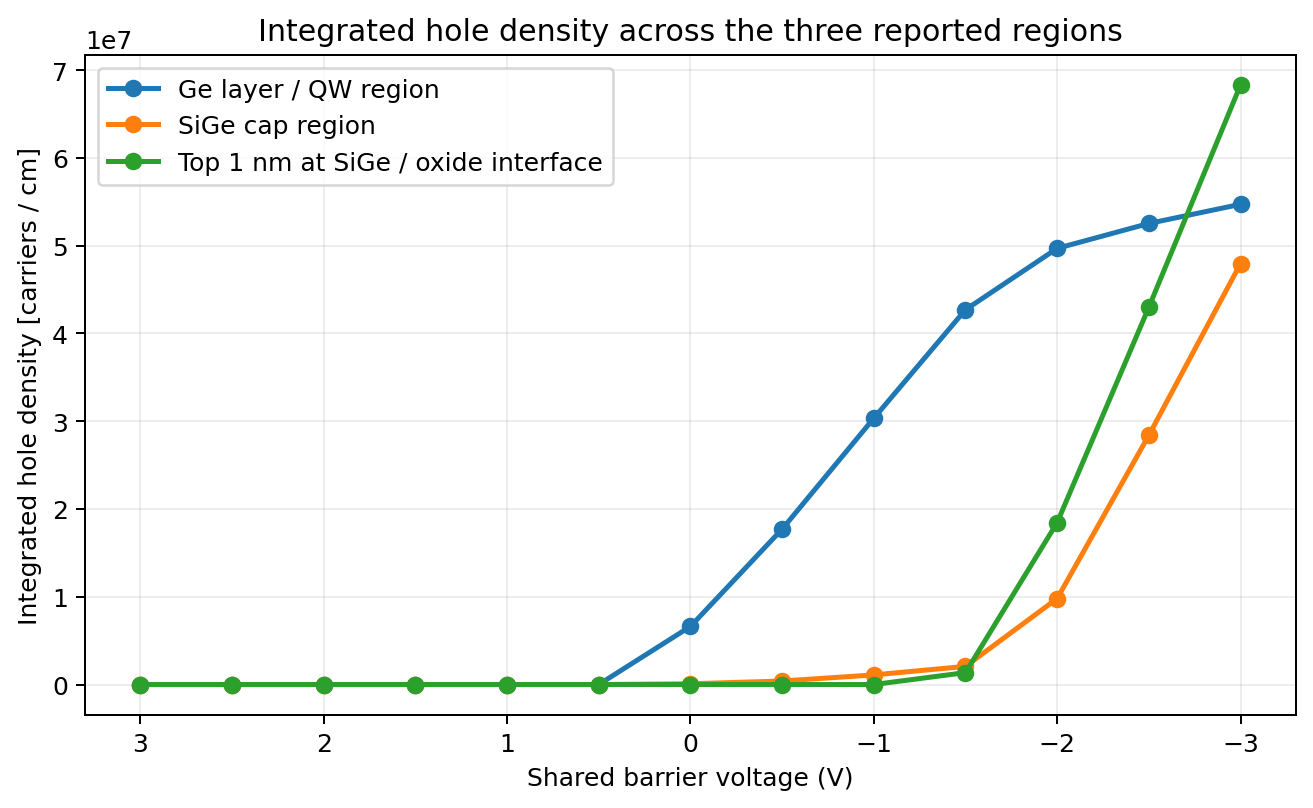

,V_BG,sheet_qw_e_per_cm,sheet_cap_e_per_cm,sheet_topcap_e_per_cm,run_name,run_root
0,3.0,1.155990e-298,1.224154e-299,1.084505e-302,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
1,2.5,1.152210e-298,1.267063e-299,1.084505e-302,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
2,2.0,1.151404e-298,1.297736e-299,1.084505e-302,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
3,1.5,1.150513e-298,1.331418e-299,1.084505e-302,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
4,1.0,1.149514e-298,1.370076e-299,1.084505e-302,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
5,0.5,1.144115e-298,1.456803e-299,1.084505e-302,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
6,0.0,6.618488e+06,8.643654e+04,1.084505e-302,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
7,-0.5,1.770254e+07,4.006875e+05,1.084505e-302,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
8,-1.0,3.033768e+07,1.094337e+06,1.084505e-302,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
9,-1.5,4.269733e+07,2.067222e+06,1.357346e+06,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...


### Total charges across runs

,V_BG,electrons_e_per_cm,holes_e_per_cm,ionized_donors_e_per_cm,ionized_acceptors_e_per_cm,fixed_charges_e_per_cm,polarization_total_e_per_cm,polarization_piezo_e_per_cm,sum_e_per_cm,run_name,run_root
0,3.000000e+00,-6.212384e+09,1.573377e-298,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-6.212384e+09,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
1,2.500000e+00,-2.258755e+09,1.574086e-298,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.258755e+09,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
2,2.000000e+00,-1.008202e+08,1.574251e-298,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.008202e+08,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
3,1.500000e+00,-5.586770e+07,1.574434e-298,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-5.586770e+07,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
4,1.000000e+00,-1.448280e+07,1.574632e-298,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.448280e+07,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
5,5.000000e-01,-1.176517e-298,1.575642e-298,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.991246e-299,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
6,0.000000e+00,-1.176517e-298,6.651586e+06,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.651586e+06,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
7,-5.000000e-01,-1.176517e-298,1.781898e+07,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.781898e+07,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
8,-1.000000e+00,-1.176517e-298,3.059138e+07,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.059138e+07,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...
9,-1.500000e+00,-1.176517e-298,4.456187e+07,0.000000e+00,-0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.456187e+07,Double_Quantum_Dot_2D_no_screening_charge__V_B...,/Users/robertjovanov/code/qpu-design-automatio...


### Requested 1D GIFs

Vertical bandedge GIFs are zoomed to the coordinate window (-60.0, 180.0) to highlight the QW-to-interface region.

#### Gamma, HH, electron Fermi level, and hole Fermi level from bandedges_1d_x_QD.dat

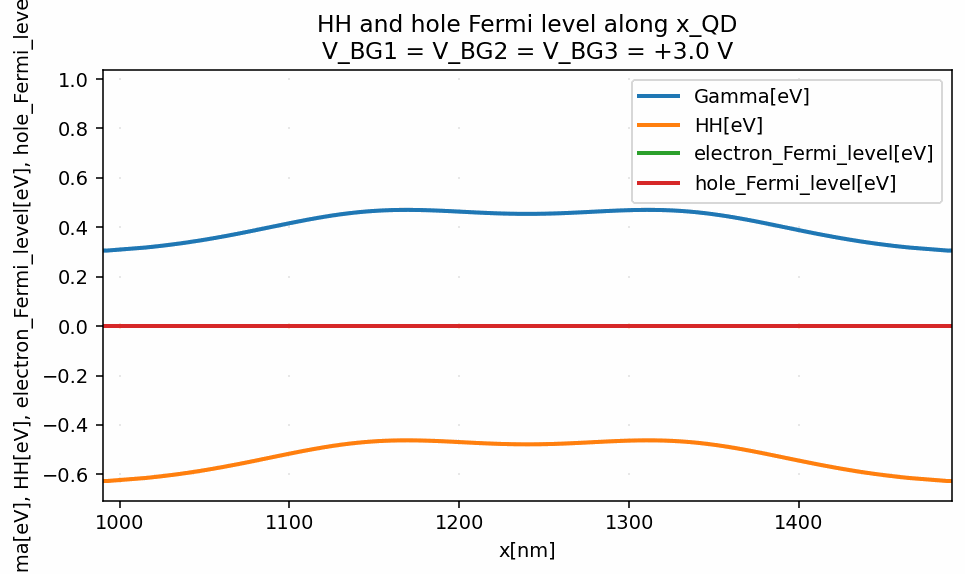

#### Gamma, HH, electron Fermi level, and hole Fermi level from bandedges_1d_z_BG2.dat

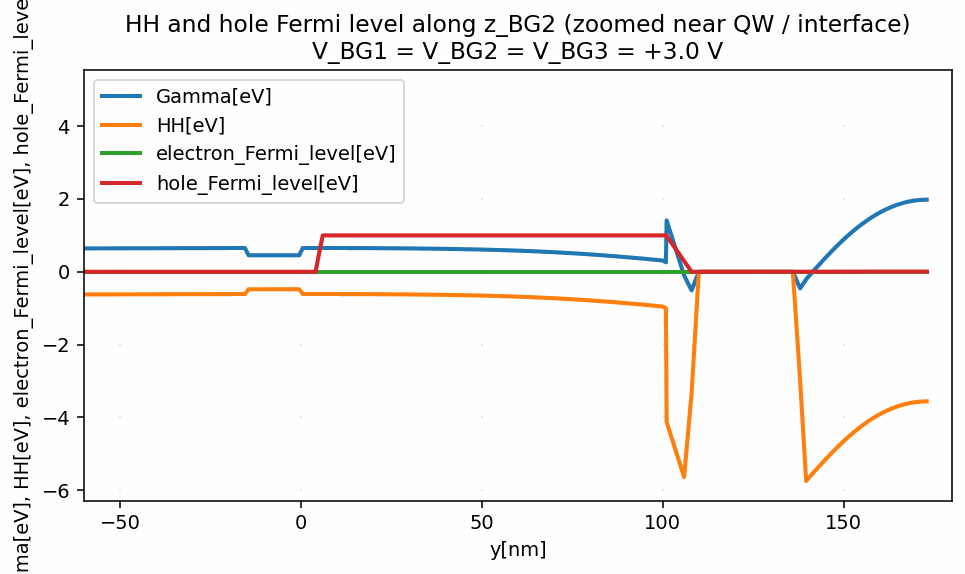

#### Gamma, HH, electron Fermi level, and hole Fermi level from bandedges_1d_z_PG1.dat

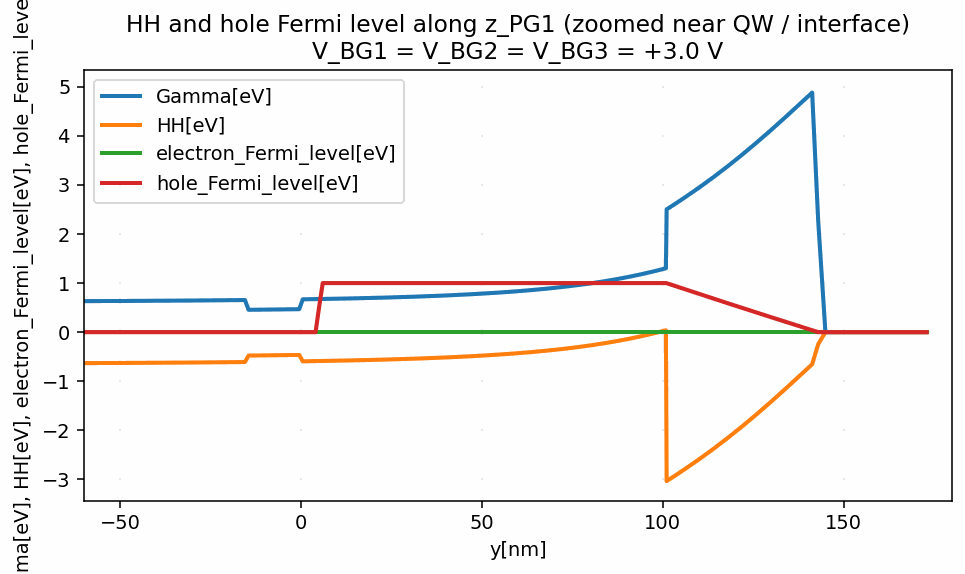

#### Potential from potential_1d_x_QD.dat

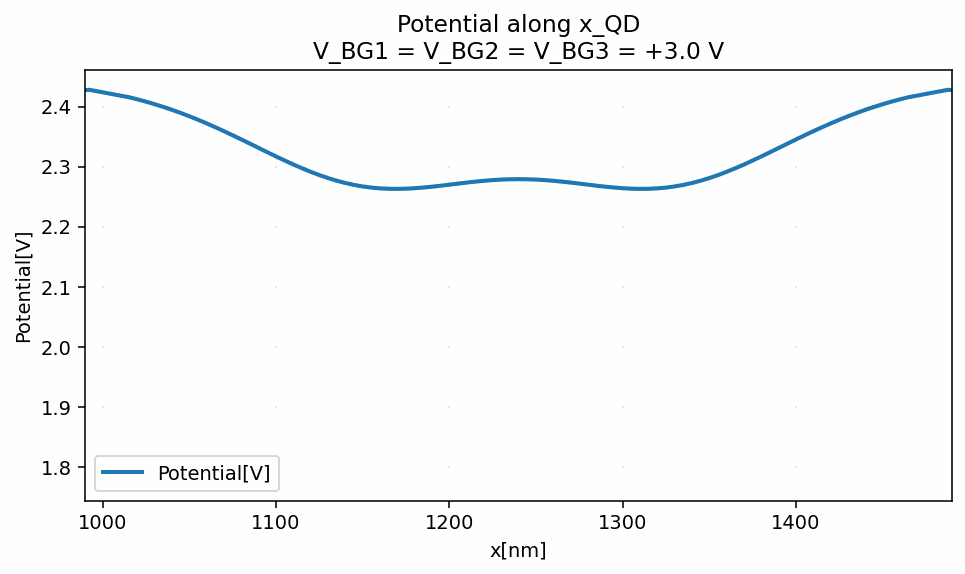

#### Classical hole density from density_hole_1d_x_QD.dat

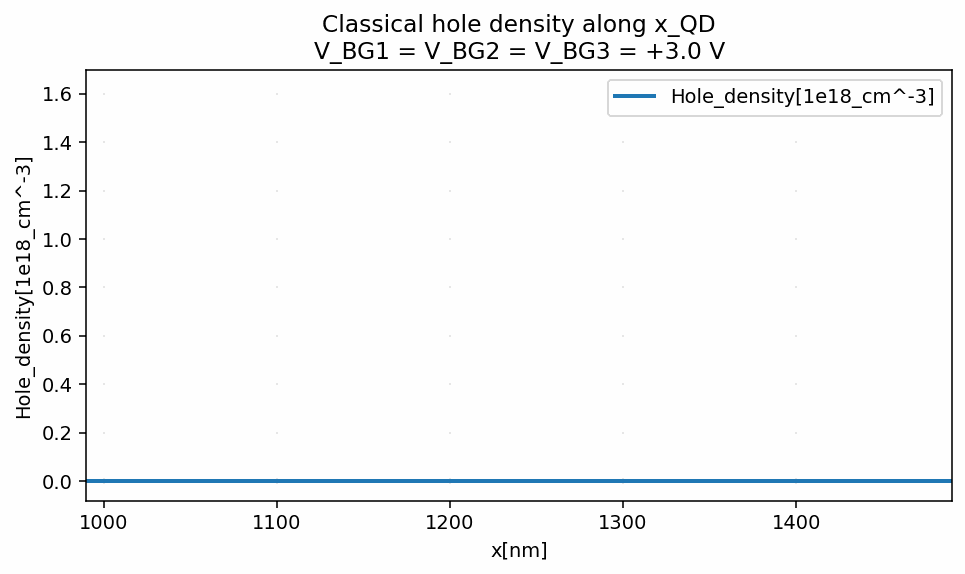

#### Quantum HH density from Quantum/c-Ge_QW/HH/density_1d_x_QD.dat

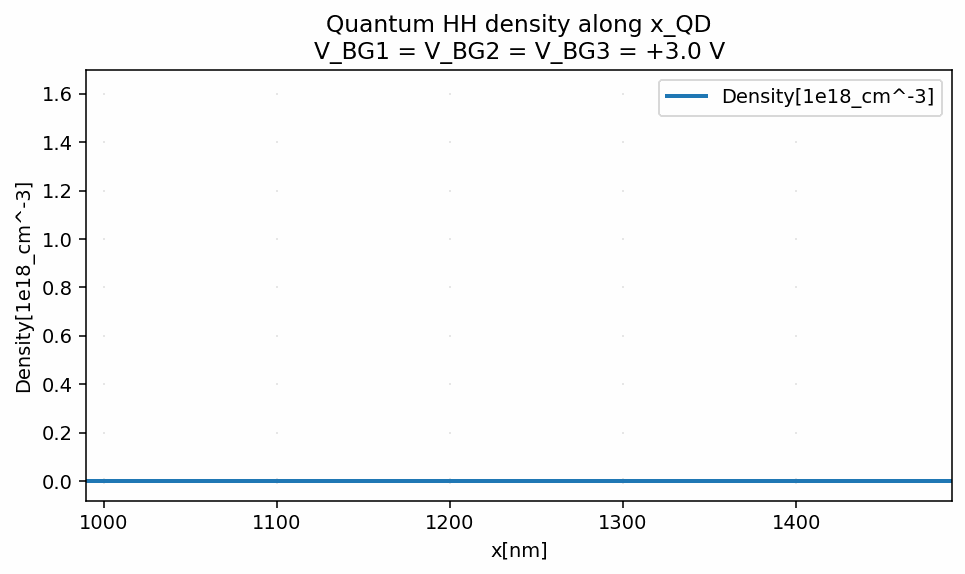

In [79]:

display(Markdown('### Integrated hole density across the three reported regions'))
display(Image(filename=str(PLOT_PATHS['integrated_density_regions'])))
display(INTEGRATED_DENSITY_SUMMARY)

display(Markdown('### Total charges across runs'))
with pd.option_context('display.float_format', '{:.6e}'.format):
    display(TOTAL_CHARGES_SUMMARY)

display(Markdown('### Requested 1D GIFs'))
display(Markdown(f'Vertical bandedge GIFs are zoomed to the coordinate window {BAND_ZOOM_WINDOW} to highlight the QW-to-interface region.'))
for key, title in DISPLAY_TITLES.items():
    display(Markdown(f"#### {title}"))
    display(Image(filename=str(GIF_PATHS[key])))


## Selected Bias Inspection

Use this section to inspect one sweep point in detail, without rebuilding the GIFs. Change `SELECTED_V_BG` to the barrier bias you want to examine, for example `-1.5`.

In [83]:
SELECTED_V_BG = 3.0
SELECTED_RUN_BIAS = 0
SELECTED_BIAS_TOL = 1e-9
SELECTED_INTERACTIVE_PLOTS = True

SELECTED_XLIM = (0, 2480)
SELECTED_MAP_ZLIM = (-4115.0, 173.0)
SELECTED_ZOOM_ZLIM = BAND_ZOOM_WINDOW

SELECTED_BANDEDGE_VARIABLES = ['Gamma', 'HH', 'electron_Fermi_level', 'hole_Fermi_level']

In [84]:

selected_diffs = np.abs(SUMMARY['V_BG'].to_numpy(dtype=float) - float(SELECTED_V_BG))
selected_idx = int(np.argmin(selected_diffs))
if selected_diffs[selected_idx] > SELECTED_BIAS_TOL:
    available = ', '.join(f'{value:+.1f}' for value in SUMMARY['V_BG'].to_numpy(dtype=float))
    raise ValueError(f'No sweep point found for V_BG={SELECTED_V_BG:+.3f} V. Available: {available}')

SELECTED_ROW = SUMMARY.iloc[selected_idx]
SELECTED_RUN_ROOT = Path(SELECTED_ROW['run_root'])
SELECTED_BIAS_DIR = nnt.get_bias_dir(SELECTED_RUN_ROOT, bias=SELECTED_RUN_BIAS)

SELECTED_GATE_X_MARKERS = [
    {'value': float(xpos), 'label': name, 'color': 'rgba(60,60,60,0.70)', 'dash': 'dash'}
    for name, xpos in X_PROBES.items()
]
def display_static_figure_once(fig):
    display(fig)
    plt.close(fig)

SELECTED_LAYER_Z_MARKERS = [
    {'value': -15.0, 'label': 'Ge QW bottom', 'color': 'rgba(40,120,70,0.75)', 'dash': 'dot'},
    {'value': 0.0, 'label': 'Ge QW top', 'color': 'rgba(40,120,70,0.75)', 'dash': 'dot'},
    {'value': 100.0, 'label': 'SiGe cap top', 'color': 'rgba(190,90,30,0.75)', 'dash': 'dot'},
]

display(Markdown(f'### Selected sweep point: V_BG1 = V_BG2 = V_BG3 = {format_bias_label(SELECTED_ROW.V_BG)}'))
display(pd.Series({
    'run_name': SELECTED_ROW.run_name,
    'run_root': str(SELECTED_RUN_ROOT),
    'nextnano_bias_dir': str(SELECTED_BIAS_DIR),
    'job_done': (SELECTED_RUN_ROOT / 'job_done.txt').exists(),
}).to_frame('value'))

display(Markdown('#### Integrated hole density regions'))
display(nnt.read_integrated_density_hole(SELECTED_RUN_ROOT / 'integrated_density_hole.dat'))
integrated_fig = nnt.plot_integrated_density_hole(
    SELECTED_RUN_ROOT,
    region_columns=['region_3[carriers/cm]', 'region_4[carriers/cm]', 'region_5[carriers/cm]'],
    interactive=SELECTED_INTERACTIVE_PLOTS,
)
if not SELECTED_INTERACTIVE_PLOTS:
    display_static_figure_once(integrated_fig)

display(Markdown('#### Total charges'))
display(nnt.read_total_charges(SELECTED_BIAS_DIR))
total_charges_fig = nnt.plot_total_charges(SELECTED_BIAS_DIR, interactive=SELECTED_INTERACTIVE_PLOTS)
if not SELECTED_INTERACTIVE_PLOTS:
    display_static_figure_once(total_charges_fig)

display(Markdown('#### Potential map: potential.fld'))
potential_map = nnt.resolve_bias_output_file(SELECTED_RUN_ROOT, 'potential', bias=SELECTED_RUN_BIAS, preferred_extensions=('fld',))
if SELECTED_INTERACTIVE_PLOTS:
    nnt.plot_fld_interactive(potential_map, title='Potential', xlim=SELECTED_XLIM, ylim=SELECTED_MAP_ZLIM, x_markers=SELECTED_GATE_X_MARKERS, y_markers=SELECTED_LAYER_Z_MARKERS, prefer_nextnanopy=False)
else:
    display_static_figure_once(nnt.plot_fld(potential_map, title='Potential', xlim=SELECTED_XLIM, ylim=SELECTED_MAP_ZLIM, x_markers=SELECTED_GATE_X_MARKERS, y_markers=SELECTED_LAYER_Z_MARKERS, prefer_nextnanopy=False))

display(Markdown('#### Classical hole density map: density_hole.fld'))
hole_density_map = nnt.resolve_bias_output_file(SELECTED_RUN_ROOT, 'density_hole', bias=SELECTED_RUN_BIAS, preferred_extensions=('fld',))
if SELECTED_INTERACTIVE_PLOTS:
    nnt.plot_fld_interactive(hole_density_map, title='Classical hole density', log10=False, xlim=SELECTED_XLIM, ylim=SELECTED_MAP_ZLIM, x_markers=SELECTED_GATE_X_MARKERS, y_markers=SELECTED_LAYER_Z_MARKERS, prefer_nextnanopy=False)
else:
    display_static_figure_once(nnt.plot_fld(hole_density_map, title='Classical hole density', log10=False, xlim=SELECTED_XLIM, ylim=SELECTED_MAP_ZLIM, x_markers=SELECTED_GATE_X_MARKERS, y_markers=SELECTED_LAYER_Z_MARKERS, prefer_nextnanopy=False))

display(Markdown('#### HH band-edge map: bandedges.fld'))
bandedge_map = nnt.resolve_bias_output_file(SELECTED_RUN_ROOT, 'bandedges', bias=SELECTED_RUN_BIAS, preferred_extensions=('fld',))
if SELECTED_INTERACTIVE_PLOTS:
    nnt.plot_fld_interactive(bandedge_map, variable='HH', title='HH band edge', xlim=SELECTED_XLIM, ylim=SELECTED_MAP_ZLIM, x_markers=SELECTED_GATE_X_MARKERS, y_markers=SELECTED_LAYER_Z_MARKERS, prefer_nextnanopy=False)
else:
    display_static_figure_once(nnt.plot_fld(bandedge_map, variable='HH', title='HH band edge', xlim=SELECTED_XLIM, ylim=SELECTED_MAP_ZLIM, x_markers=SELECTED_GATE_X_MARKERS, y_markers=SELECTED_LAYER_Z_MARKERS, prefer_nextnanopy=False))

display(Markdown('#### Electric-field norm map: electric_field_norm.fld'))
efield_map = nnt.resolve_bias_output_file(SELECTED_RUN_ROOT, 'electric_field_norm', bias=SELECTED_RUN_BIAS, preferred_extensions=('fld',))
if SELECTED_INTERACTIVE_PLOTS:
    nnt.plot_fld_interactive(efield_map, title='Electric-field norm', xlim=SELECTED_XLIM, ylim=SELECTED_MAP_ZLIM, x_markers=SELECTED_GATE_X_MARKERS, y_markers=SELECTED_LAYER_Z_MARKERS, prefer_nextnanopy=False)
else:
    display_static_figure_once(nnt.plot_fld(efield_map, title='Electric-field norm', xlim=SELECTED_XLIM, ylim=SELECTED_MAP_ZLIM, x_markers=SELECTED_GATE_X_MARKERS, y_markers=SELECTED_LAYER_Z_MARKERS, prefer_nextnanopy=False))

display(Markdown('#### Band edges along x_QD: bandedges_1d_x_QD.dat'))
bandedges_x = nnt.resolve_bias_output_file(SELECTED_RUN_ROOT, 'bandedges', cut='1d_x_QD', bias=SELECTED_RUN_BIAS, preferred_extensions=('dat',))
if SELECTED_INTERACTIVE_PLOTS:
    nnt.plot_dat_interactive(bandedges_x, variables=SELECTED_BANDEDGE_VARIABLES, title='Band edges along x_QD', xlim=SELECTED_XLIM, markers=SELECTED_GATE_X_MARKERS, prefer_nextnanopy=False)
else:
    display_static_figure_once(nnt.plot_dat(bandedges_x, variables=SELECTED_BANDEDGE_VARIABLES, title='Band edges along x_QD', xlim=SELECTED_XLIM, markers=SELECTED_GATE_X_MARKERS, prefer_nextnanopy=False))

display(Markdown('#### Band edges along z_BG2: bandedges_1d_z_BG2.dat'))
bandedges_z_bg2 = nnt.resolve_bias_output_file(SELECTED_RUN_ROOT, 'bandedges', cut='1d_z_BG2', bias=SELECTED_RUN_BIAS, preferred_extensions=('dat',))
if SELECTED_INTERACTIVE_PLOTS:
    nnt.plot_dat_interactive(bandedges_z_bg2, variables=SELECTED_BANDEDGE_VARIABLES, title='Band edges along z_BG2', xlim=SELECTED_ZOOM_ZLIM, markers=SELECTED_LAYER_Z_MARKERS, prefer_nextnanopy=False)
else:
    display_static_figure_once(nnt.plot_dat(bandedges_z_bg2, variables=SELECTED_BANDEDGE_VARIABLES, title='Band edges along z_BG2', xlim=SELECTED_ZOOM_ZLIM, markers=SELECTED_LAYER_Z_MARKERS, prefer_nextnanopy=False))

display(Markdown('#### Band edges along z_PG1: bandedges_1d_z_PG1.dat'))
bandedges_z_pg1 = nnt.resolve_bias_output_file(SELECTED_RUN_ROOT, 'bandedges', cut='1d_z_PG1', bias=SELECTED_RUN_BIAS, preferred_extensions=('dat',))
if SELECTED_INTERACTIVE_PLOTS:
    nnt.plot_dat_interactive(bandedges_z_pg1, variables=SELECTED_BANDEDGE_VARIABLES, title='Band edges along z_PG1', xlim=SELECTED_ZOOM_ZLIM, markers=SELECTED_LAYER_Z_MARKERS, prefer_nextnanopy=False)
else:
    display_static_figure_once(nnt.plot_dat(bandedges_z_pg1, variables=SELECTED_BANDEDGE_VARIABLES, title='Band edges along z_PG1', xlim=SELECTED_ZOOM_ZLIM, markers=SELECTED_LAYER_Z_MARKERS, prefer_nextnanopy=False))

display(Markdown('#### Potential along x_QD: potential_1d_x_QD.dat'))
potential_x = nnt.resolve_bias_output_file(SELECTED_RUN_ROOT, 'potential', cut='1d_x_QD', bias=SELECTED_RUN_BIAS, preferred_extensions=('dat',))
if SELECTED_INTERACTIVE_PLOTS:
    nnt.plot_dat_interactive(potential_x, title='Potential along x_QD', xlim=SELECTED_XLIM, markers=SELECTED_GATE_X_MARKERS, prefer_nextnanopy=False)
else:
    display_static_figure_once(nnt.plot_dat(potential_x, title='Potential along x_QD', xlim=SELECTED_XLIM, markers=SELECTED_GATE_X_MARKERS, prefer_nextnanopy=False))

display(Markdown('#### Classical hole density along x_QD: density_hole_1d_x_QD.dat'))
classical_hole_x = nnt.resolve_bias_output_file(SELECTED_RUN_ROOT, 'density_hole', cut='1d_x_QD', bias=SELECTED_RUN_BIAS, preferred_extensions=('dat',))
if SELECTED_INTERACTIVE_PLOTS:
    nnt.plot_dat_interactive(classical_hole_x, title='Classical hole density along x_QD', xlim=SELECTED_XLIM, yscale='linear', markers=SELECTED_GATE_X_MARKERS, prefer_nextnanopy=False)
else:
    display_static_figure_once(nnt.plot_dat(classical_hole_x, title='Classical hole density along x_QD', xlim=SELECTED_XLIM, yscale='linear', markers=SELECTED_GATE_X_MARKERS, prefer_nextnanopy=False))

display(Markdown('#### Quantum HH density along x_QD: Quantum/c-Ge_QW/HH/density_1d_x_QD.dat'))
quantum_hh_x = nnt.resolve_quantum_output_file(SELECTED_RUN_ROOT, 'density', cut='1d_x_QD', region='c-Ge_QW', band='HH', bias=SELECTED_RUN_BIAS, preferred_extensions=('dat',))
if SELECTED_INTERACTIVE_PLOTS:
    nnt.plot_dat_interactive(quantum_hh_x, title='Quantum HH density along x_QD', xlim=SELECTED_XLIM, yscale='linear', markers=SELECTED_GATE_X_MARKERS, prefer_nextnanopy=False)
else:
    display_static_figure_once(nnt.plot_dat(quantum_hh_x, title='Quantum HH density along x_QD', xlim=SELECTED_XLIM, yscale='linear', markers=SELECTED_GATE_X_MARKERS, prefer_nextnanopy=False))


### Selected sweep point: V_BG1 = V_BG2 = V_BG3 = +3.0 V

,value
run_name,Double_Quantum_Dot_2D_no_screening_charge__V_B...
run_root,/Users/robertjovanov/code/qpu-design-automatio...
nextnano_bias_dir,/Users/robertjovanov/code/qpu-design-automatio...
job_done,True


#### Integrated hole density regions

,BG1_bias[V],PG1_bias[V],BG2_bias[V],PG2_bias[V],BG3_bias[V],Source_bias[V],Drain_bias[V],Body_bias[V],remove_surface_charge_bias[V],zero_fermi_QW_bias[V],region_3[carriers/cm],region_4[carriers/cm],region_5[carriers/cm]
0,0,0,0,0,0,0,0,0,-1,0,1.155990e-298,1.224154e-299,1.084505e-302


#### Total charges

...

#### Band edges along z_BG2: bandedges_1d_z_BG2.dat

#### Band edges along z_PG1: bandedges_1d_z_PG1.dat

#### Potential along x_QD: potential_1d_x_QD.dat

#### Classical hole density along x_QD: density_hole_1d_x_QD.dat

#### Quantum HH density along x_QD: Quantum/c-Ge_QW/HH/density_1d_x_QD.dat